# Day23
01-Apr-25

In [4]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

import statsmodels.formula.api as smf
from statsmodels.graphics.regressionplots import influence_plot

In [5]:
import warnings
warnings.filterwarnings('ignore')

### Step 1 - Read the data 
Problem - predict the mileage based

In [9]:
cars_mil=pd.read_csv('Cars.csv')
cars_mil.head(5)

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149


In [11]:
cars_mil.shape

(81, 5)

In [13]:
cars_mil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HP      81 non-null     int64  
 1   MPG     81 non-null     float64
 2   VOL     81 non-null     int64  
 3   SP      81 non-null     float64
 4   WT      81 non-null     float64
dtypes: float64(3), int64(2)
memory usage: 3.3 KB


In [15]:
cars_mil.describe()

,HP,MPG,VOL,SP,WT
count,81.000000,81.000000,81.000000,81.000000,81.000000
mean,117.469136,34.422076,98.765432,121.540272,32.412577
std,57.113502,9.131445,22.301497,14.181432,7.492813
min,49.000000,12.101263,50.000000,99.564907,15.712859
25%,84.000000,27.856252,89.000000,113.829145,29.591768
50%,100.000000,35.152727,101.000000,118.208698,32.734518
75%,140.000000,39.531633,113.000000,126.404312,37.392524
max,322.000000,53.700681,160.000000,169.598513,52.997752


### Step 2 - check x can be used to predict Y 

#### step 2.1.1 Scatter plot

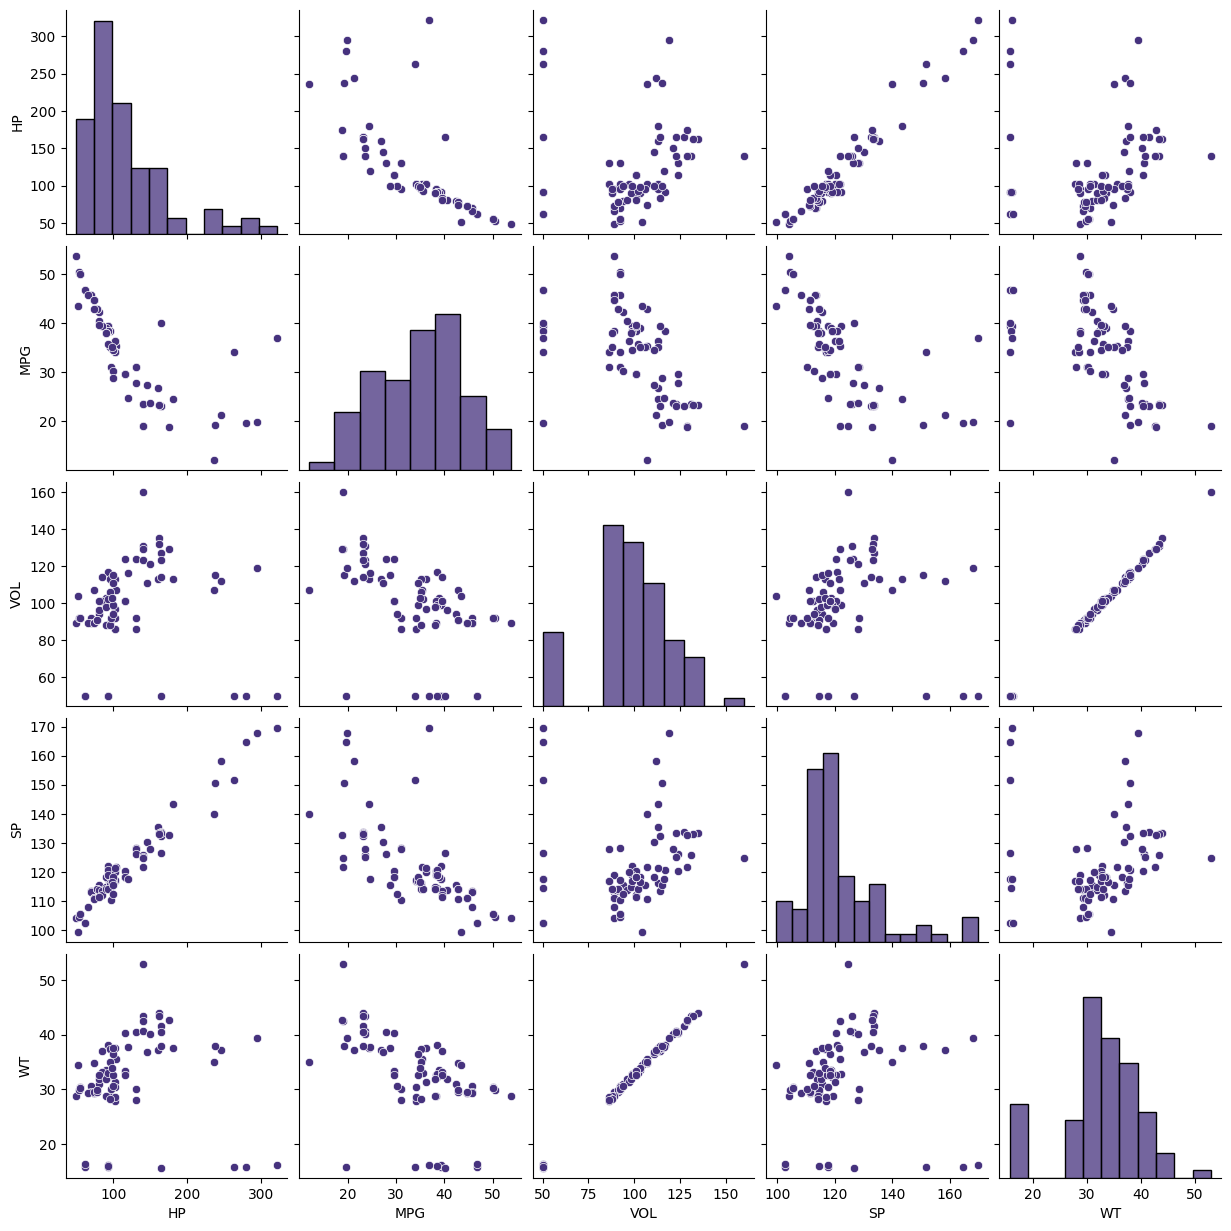

In [19]:
sns.set_palette('viridis') # for colour - optional
sns.set_style='whitegrid' #optinal
sns.pairplot(cars_mil) # mandatory
plt.show()

- Almost all the features are having correlation(negative) with target column i.e.MPEG, means all are relavent ferature to predict the Y
- But there are some idepenedent feature(WT vs VOL) are higly corelated with each, ideally which should not have. So id does not make any sense to
  use both of the column in analysis, going forward we will drop one

#### step 2.1.2 Correlation matrix

In [23]:
corr=cars_mil.corr()
print(corr)
print(type(corr))

           HP       MPG       VOL        SP        WT
HP   1.000000 -0.725038  0.077459  0.973848  0.076513
MPG -0.725038  1.000000 -0.529057 -0.687125 -0.526759
VOL  0.077459 -0.529057  1.000000  0.102170  0.999203
SP   0.973848 -0.687125  0.102170  1.000000  0.102439
WT   0.076513 -0.526759  0.999203  0.102439  1.000000
<class 'pandas.core.frame.DataFrame'>


In [25]:
print(corr['MPG'].sort_values(ascending=True)) # only with respect to target column

HP    -0.725038
SP    -0.687125
VOL   -0.529057
WT    -0.526759
MPG    1.000000
Name: MPG, dtype: float64


<Axes: >

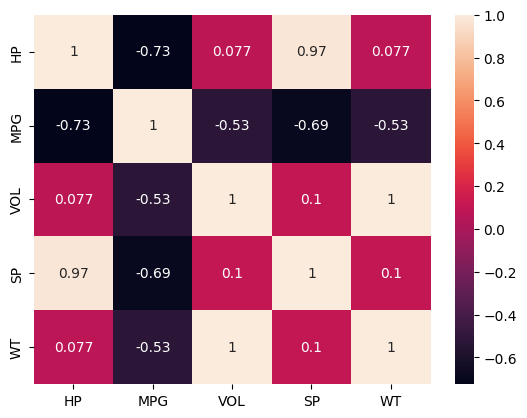

In [27]:
sns.heatmap(corr,annot=True) # Annot will provide numbers

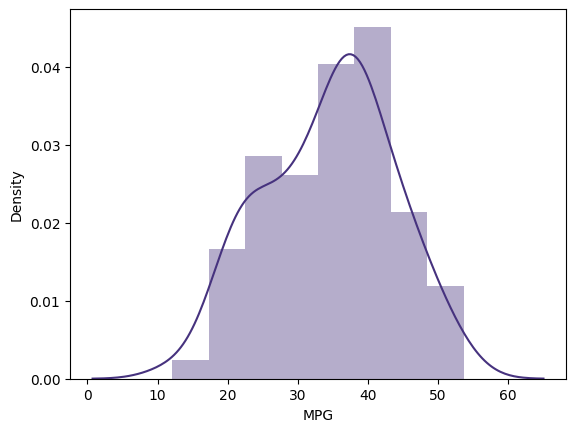

In [29]:
sns.distplot(cars_mil['MPG'])
plt.show()

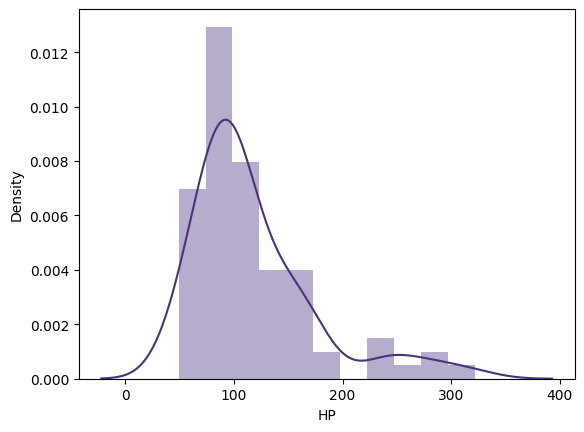

In [31]:
sns.distplot(cars_mil['HP'])
plt.show()

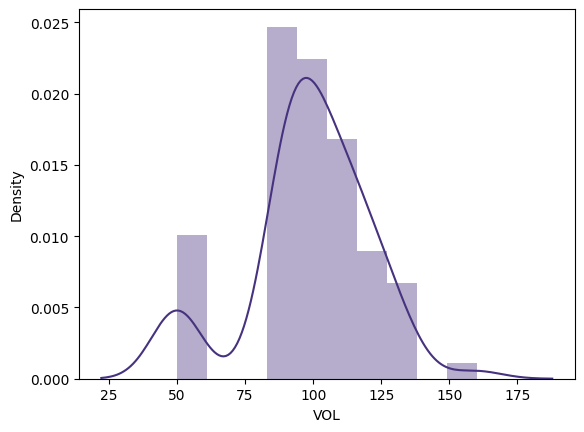

In [33]:
sns.distplot(cars_mil['VOL'])
plt.show()

### Step 3 - Build the model

In [36]:
cars=smf.ols('MPG~WT+VOL+SP+HP',data=cars_mil)
cars_model=cars.fit()
# cars_model=smf.ols('MPG~WT+VOL+SP+HP',data=cars_mil).fit() -- rather than using 2 lines we can use one line only

In [38]:
cars_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    MPG   R-squared:                       0.771
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     63.80
Date:                Tue, 02 Sep 2025   Prob (F-statistic):           1.54e-23
Time:                        17:20:34   Log-Likelihood:                -233.96
No. Observations:                  81   AIC:                             477.9
Df Residuals:                      76   BIC:                             489.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     30.6773     14.900      2.059      0.043       1.001      60.354
WT             0.4006      1.693      0.237      0.814      -2.972       3.773
VOL           -0.3361      0.569     -0.591      0.556      -1.469       0.796
SP             0.3956      0.158      2.500      0.015       0.080       0.711
HP            -0.2054      0.039     -5.239      0.000      -0.284      -0.127
==============================================================================
Omnibus:                       10.780   Durbin-Watson:                   1.403
Prob(Omnibus):                  0.005   Jarque-Bera (JB):               11.722
Skew:                           0.707   Prob(JB):                      0.00285
Kurtosis:                       4.215   Cond. No.                     6.09e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.09e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

- Smmary analysis
- Rsquare should be more than 0.85 but model has not given us, so need to work more on model and improve.

- Here the null hypothesis is B1=0, B2=0, B3=0, B4=0
- alpha for B1(WT) is 0.814, which is >0.05, we accept the null hypothesis, so WT is not good predictor MPG.
- alpha for B2(VOL) is 0.556, which is >0.05, we accept the null hypothesis, so VOL is not good predictor MPG.
- alpha for B3(SP) is 0.015, which is <0.05, we reject the null hypothesis, so SP is  good predictor MPG.
- alpha for B4(HP) is 0.000, which is <0.05, we reject the null hypothesis, so HP is  good predictor MPG.

- But if we think wight and Volume defenetely impacts mileage but why our model is not showing that, because high correlation between wight and colume.
- we can not ignore column only with this analysis will do some more analysis

In [41]:
cars_model.params

Intercept    30.677336
WT            0.400574
VOL          -0.336051
SP            0.395627
HP           -0.205444
dtype: float64

- Intercept - Betanot -  30.677336
- WT   -  B1   -    0.400574
- VOL - B2-        0.336051
- SP    -B3-        0.395627
- HP     -B4-      -0.205444

### Step 3.1 
As model says WT and Vol are not good predictor for MPG, but common sense says it will impact. lets build the model individually and check

In [45]:
cars_wt=smf.ols('MPG~WT',data=cars_mil)
cars_wt_model=cars_wt.fit()

In [47]:
cars_wt_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    MPG   R-squared:                       0.277
Model:                            OLS   Adj. R-squared:                  0.268
Method:                 Least Squares   F-statistic:                     30.34
Date:                Tue, 02 Sep 2025   Prob (F-statistic):           4.38e-07
Time:                        17:20:37   Log-Likelihood:                -280.42
No. Observations:                  81   AIC:                             564.8
Df Residuals:                      79   BIC:                             569.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     55.2296      3.876     14.249      0.000      47.514      62.945
WT            -0.6420      0.117     -5.508      0.000      -0.874      -0.410
==============================================================================
Omnibus:                        2.735   Durbin-Watson:                   0.555
Prob(Omnibus):                  0.255   Jarque-Bera (JB):                2.045
Skew:                          -0.263   Prob(JB):                        0.360
Kurtosis:                       3.573   Cond. No.                         149.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [49]:
- Summary analysis
- If we see Rsquare is 27, means it carries almost 27% wightage, which is not bad.

SyntaxError: invalid syntax (2887299039.py, line 1)

In [51]:
cars_vol=smf.ols('MPG~VOL',data=cars_mil)
cars_vol_model=cars_vol.fit()

In [53]:
cars_vol_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    MPG   R-squared:                       0.280
Model:                            OLS   Adj. R-squared:                  0.271
Method:                 Least Squares   F-statistic:                     30.71
Date:                Tue, 02 Sep 2025   Prob (F-statistic):           3.82e-07
Time:                        17:20:39   Log-Likelihood:                -280.28
No. Observations:                  81   AIC:                             564.6
Df Residuals:                      79   BIC:                             569.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     55.8171      3.957     14.106      0.000      47.941      63.693
VOL           -0.2166      0.039     -5.541      0.000      -0.294      -0.139
==============================================================================
Omnibus:                        2.691   Durbin-Watson:                   0.566
Prob(Omnibus):                  0.260   Jarque-Bera (JB):                1.997
Skew:                          -0.263   Prob(JB):                        0.368
Kurtosis:                       3.562   Cond. No.                         462.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [55]:
- Summary analysis
- If we see Rsquare is 28, means it carries almost 28% wightage, which is not bad.

SyntaxError: invalid syntax (2091952641.py, line 1)

In [57]:
cars_wt_vol=smf.ols('MPG~WT+VOL',data=cars_mil)
cars_wt_vol_model=cars_wt_vol.fit()

In [59]:
cars_wt_vol_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    MPG   R-squared:                       0.282
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                     15.33
Date:                Tue, 02 Sep 2025   Prob (F-statistic):           2.43e-06
Time:                        17:20:42   Log-Likelihood:                -280.16
No. Observations:                  81   AIC:                             566.3
Df Residuals:                      78   BIC:                             573.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     56.8847      4.534     12.546      0.000      47.858      65.912
WT             1.4349      2.929      0.490      0.626      -4.397       7.266
VOL           -0.6983      0.984     -0.710      0.480      -2.658       1.261
==============================================================================
Omnibus:                        2.405   Durbin-Watson:                   0.591
Prob(Omnibus):                  0.300   Jarque-Bera (JB):                1.712
Skew:                          -0.251   Prob(JB):                        0.425
Kurtosis:                       3.506   Cond. No.                         597.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

-- If we see the individual Rsqaure and combine is not making much difference, mweans we can drop any one column whose Rsquare is less.
-- But we can not drop directly we need to calculate VIF

### Step 3.2 Variance inflation Factor - to decide which collumn we need to drop

In [63]:
'''cars_model_hp_target=smf.ols('HP~WT+VOL+SP',data=cars_mil)
cars_model_hp_target_model=cars_model_hp_target.fit()
cars_model_hp_target_model.rsquared'''

# Or we can right above 3 line code in one line
rsq_hp=smf.ols('HP~WT+VOL+SP',data=cars_mil).fit().rsquared
vif_hp=1/(1-rsq_hp)

rsq_wt=smf.ols('WT~HP+VOL+SP',data=cars_mil).fit().rsquared
vif_wt=1/(1-rsq_wt)

rsq_vol=smf.ols('VOL~WT+HP+SP',data=cars_mil).fit().rsquared
vif_vol=1/(1-rsq_vol)

rsq_sp=smf.ols('SP~WT+VOL+HP',data=cars_mil).fit().rsquared
vif_sp=1/(1-rsq_sp)

In [65]:
# storing VIF in one dataframe
df1={'Varaibles':['HP','WT','VOL','SP'],'VIF':[vif_hp,vif_wt,vif_vol,vif_sp]}
type(df1)
vif_dframe=pd.DataFrame(df1)
vif_dframe

,Varaibles,VIF
0,HP,19.926589
1,WT,639.533818
2,VOL,638.806084
3,SP,20.007639


- As VIF value of all feature is more than 10,so all the feature are highly corelated with HP(This indicates multiconlinearity)
- As we see above for weight and vol VIF is very high. BUt if we compare  R2 of both, vol is having better Rsquare than WT and VIF is less than 
    WT. So we can conclude that, VOL is better predictor of mileage compare to WT.
- So we can drop WT
- For HP and SP VIF is > 10, ideally it should not but as we dont haave any other feature, we no option.

### Step 3.3 Residual analysis

#### Step 3.3.1 Residual mean should be close to zero

In [70]:
cars_model.resid # this willl return rsidual (error = y-yhat) for each datapoint

0     10.258747
1      7.624608
2      7.734060
3      3.157963
4      8.331584
        ...    
76    15.617904
77     1.298838
78     7.863547
79     7.517122
80    -3.458218
Length: 81, dtype: float64

In [72]:
cars_model.resid.mean() 

5.3488078164163097e-14

In [74]:
cars_model.fittedvalues # cars_model.fittedvalues refers to the predicted values of the dependent variable (y) based on the model you've fitted.


0     43.441935
1     42.388793
2     42.279341
3     42.538360
4     42.172648
        ...    
76    21.282096
77    17.899050
78    26.136453
79    12.316612
80    15.559481
Length: 81, dtype: float64

#### Step 3.3.2 Residual should be normally distributed - we can use KDE plot and Q-Q plot to check normal distribution

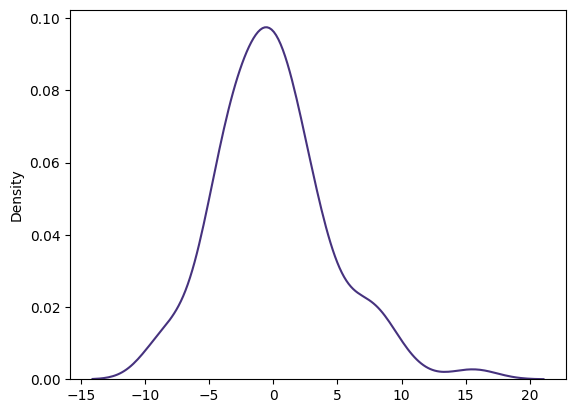

In [77]:
sns.kdeplot(cars_model.resid) # this plot shows residuals are almost normally distributed
plt.show()

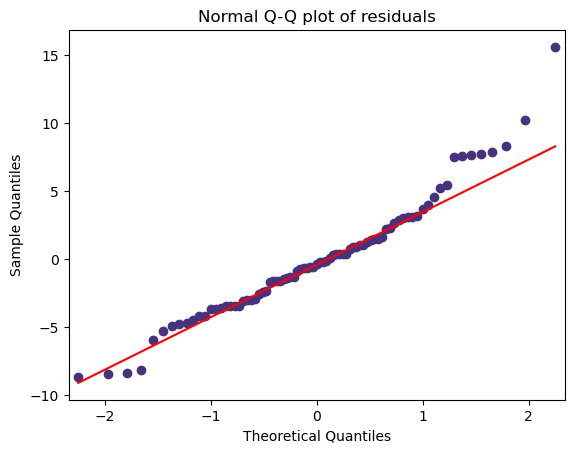

"The Q-Q plot is used to check whether the residuals from a regression model follow a normal distribution. \nIf the points on the plot lie approximately on a straight line (especially if it's the line='q' version), \nit suggests that the residuals are normally distributed. If the points deviate significantly from the line, \nit suggests that the residuals are not normally distributed."

In [146]:
qqplot=sm.qqplot(cars_model.resid,line='q') #line=45 to draw the diagonal value
plt.title('Normal Q-Q plot of residuals')
plt.show() 
# here red line represents theorotical distribution(normal distribution) and all our data pints follows that theorotical lline.
# here we are comparing error values of model and theorotical values of normal distribution
'''The Q-Q plot is used to check whether the residuals from a regression model follow a normal distribution. 
If the points on the plot lie approximately on a straight line (especially if it's the line='q' version), 
it suggests that the residuals are normally distributed. If the points deviate significantly from the line, 
it suggests that the residuals are not normally distributed.'''

#### Step 3.3.3 Residual should have constant variance

In [149]:
def get_standerdized_values(vals):
    return (vals-vals.mean())/vals.std() # created function to get standardised value

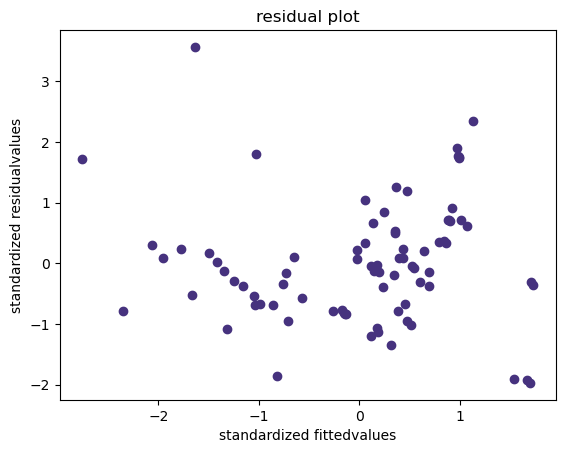

In [151]:
plt.scatter(get_standerdized_values(cars_model.fittedvalues),get_standerdized_values(cars_model.resid))
plt.title('residual plot')
plt.xlabel('standardized fittedvalues')
plt.ylabel('standardized residualvalues')
plt.show()

- By looking at the above plot we can say that
- 1) Mean roughly around 0
- 2) Resuduals has uniform disrubution
- 3) Residual has constant variance


In [ ]:
pyplot.plt(figsize=figure(6,6))

### Step 3.4 Residual Vs regressor - Partial regressor plot
- If model is not satisfying residual analysis, then we need to and check correct features with the help of Residual Vs regressor plot
- This will build a model for each individual feature with target variable
- We use Residual vs Regressor (or vs Fitted) plots to check regression assumptions:

- Linearity

- Constant variance

- Outliers

- Independence

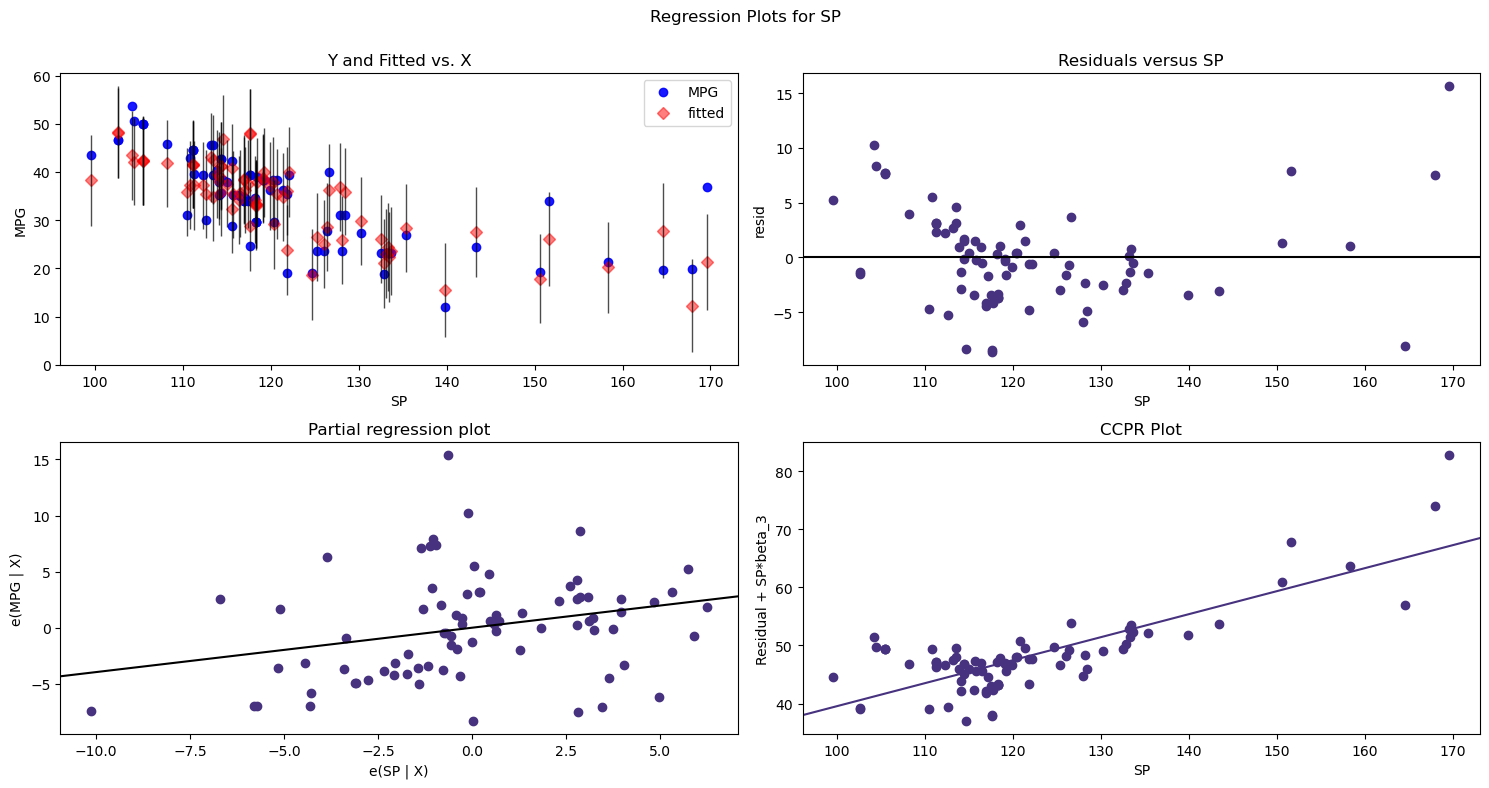

In [268]:
fig = plt.figure(figsize=(15,8))
fig = sm.graphics.plot_regress_exog(cars_model,'SP',fig=fig)
plt.show()
# Y and fitted vs x plot - shows the predictd and actal value for the input of SP column
# Residual vs SP - this plot shows actual error value(actual - predicted)
# partial regression - it talks about influesnce of SP feature on target variable. if line is slanting then it has impact on target feature. means we can consider this feature to predict y


In [ ]:
- By lookig at the above plots of SP we can say that SP i scontrubuting to predict the Y. So we can not build the model without SP.

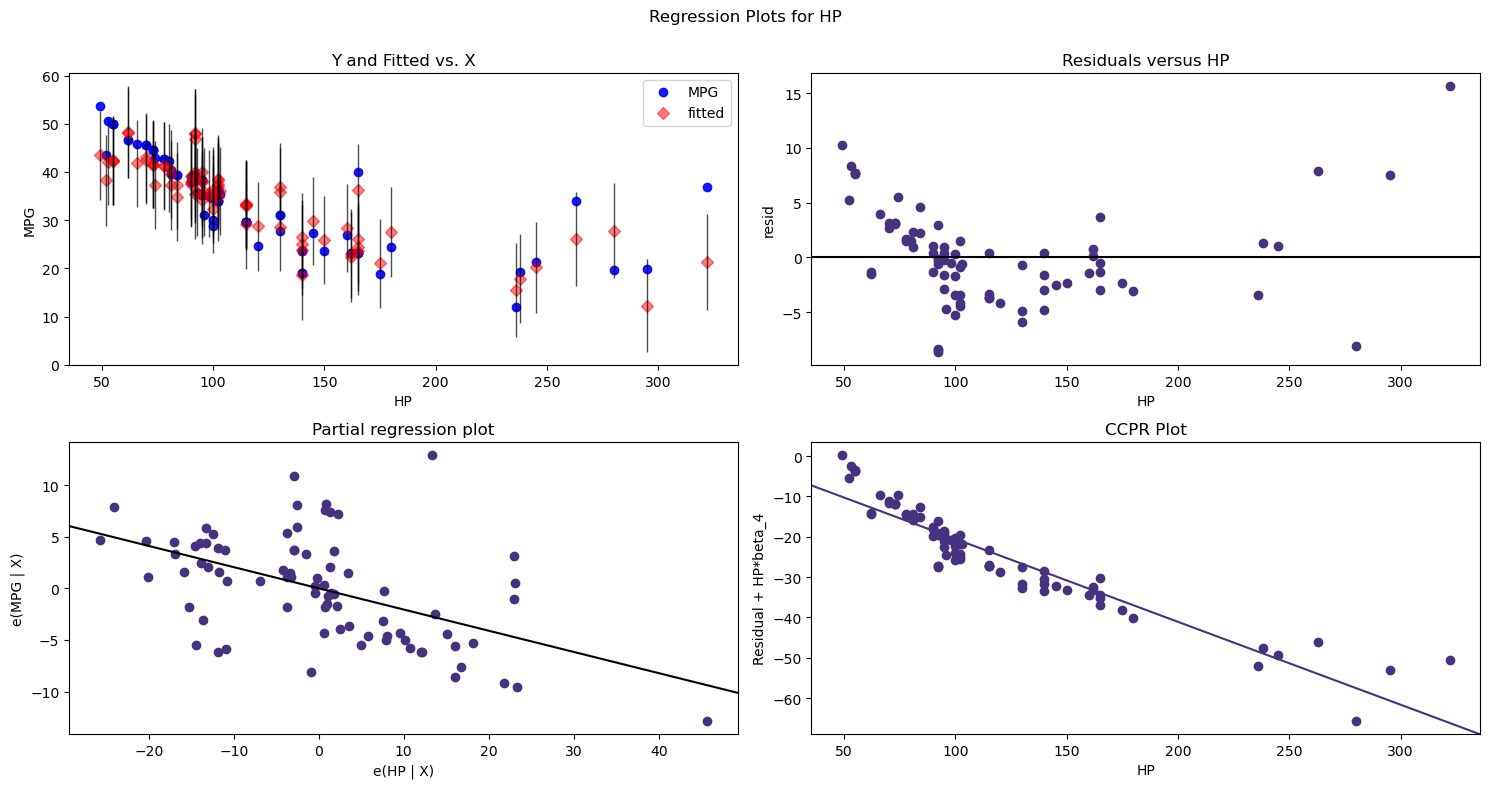

In [270]:
fig = plt.figure(figsize=(15,8))
fig = sm.graphics.plot_regress_exog(cars_model,'HP',fig=fig)
plt.show()

In [ ]:
- By lookig at the above plots of HP we can say that HP i scontrubuting to predict the Y. So we can not build the model without HP.

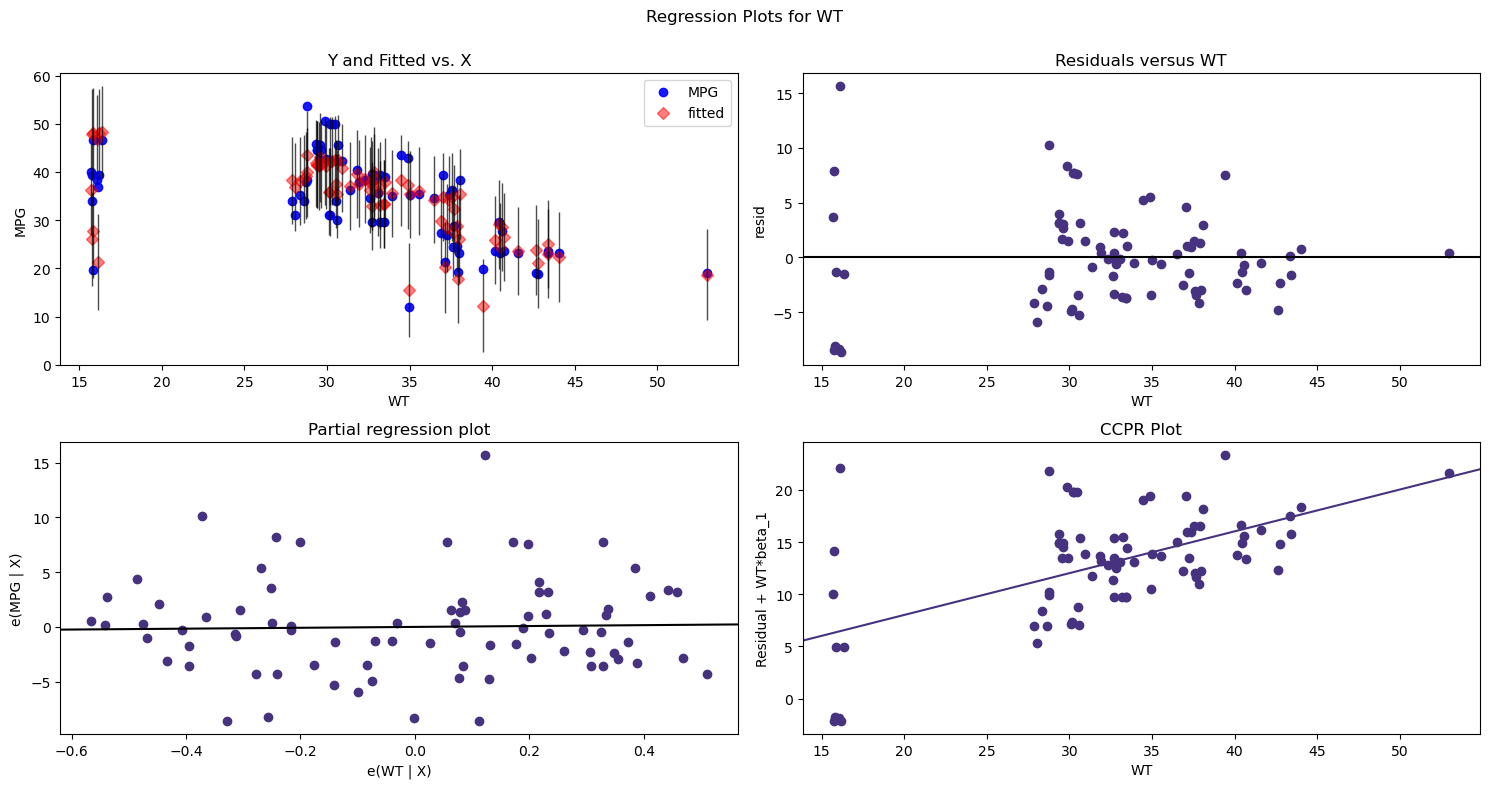

In [272]:
fig = plt.figure(figsize=(15,8))
fig = sm.graphics.plot_regress_exog(cars_model,'WT',fig=fig)
plt.show()

- By lookig at the above plots of wt we can say that, WT is not satisfying the homoscadiscity and normal distribution. So we can say that WT is not a good predictor and we remove this feature

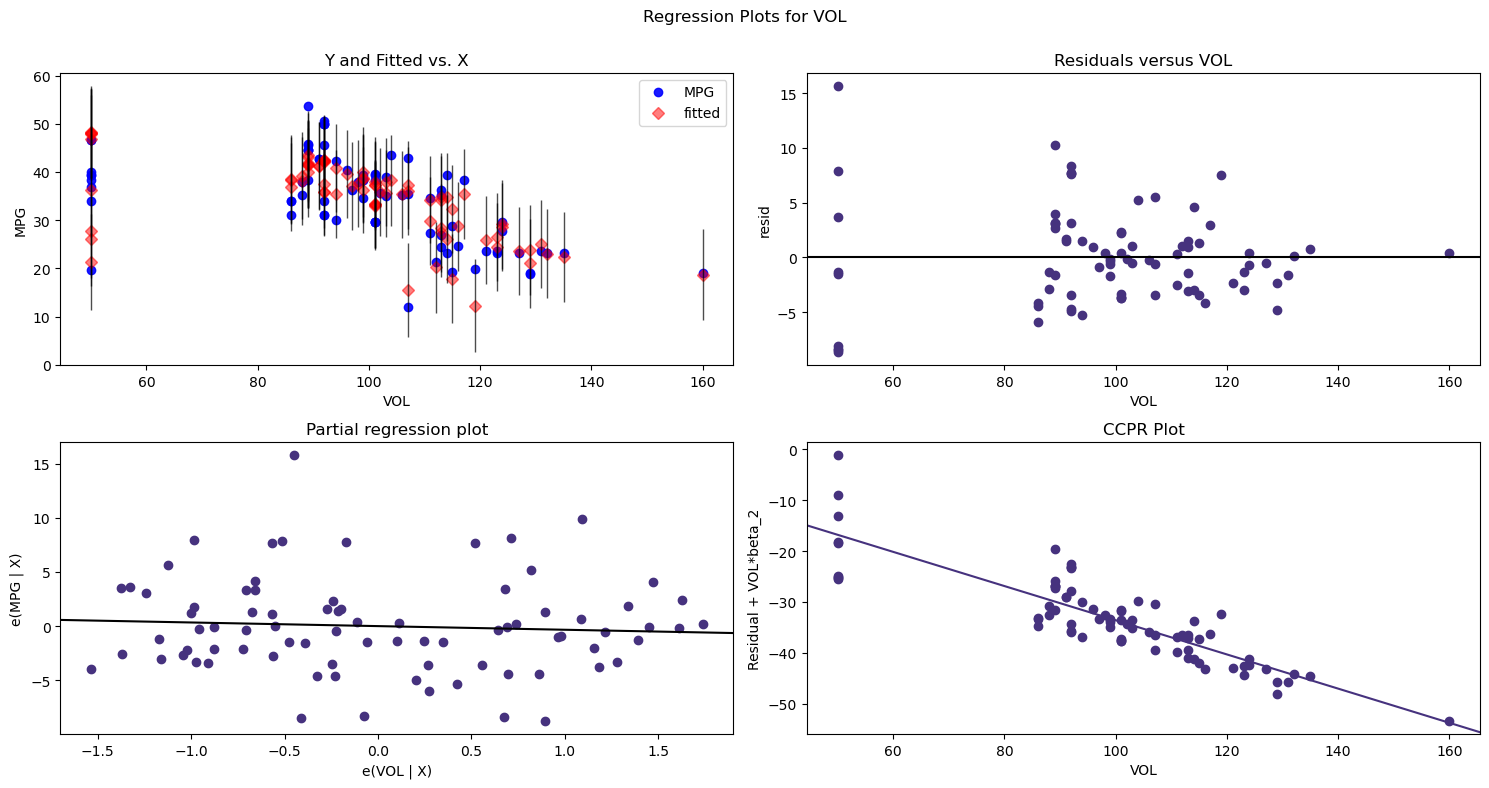

In [274]:
fig = plt.figure(figsize=(15,8))
fig = sm.graphics.plot_regress_exog(cars_model,'VOL',fig=fig)
plt.show()

- By lookig at the above plots of VOL we can say that, VOL is contrubuting to predict the Y. So we can not build the model without HP.

# Model Deletion Diagnostics

## Detecting Outliers and Influencial point

### Cook's distance - it i sused for only regression models

In [167]:
- Till now we have dropeed problematic column or unwanted column by using residual analysis method.
- Now we will drop prblematic records by using OUTLIER and INFLUENCIAL POINT.

SyntaxError: invalid syntax (3247049428.py, line 1)

In [169]:
model_influence = cars_model.get_influence()
(c, _) = model_influence.cooks_distance

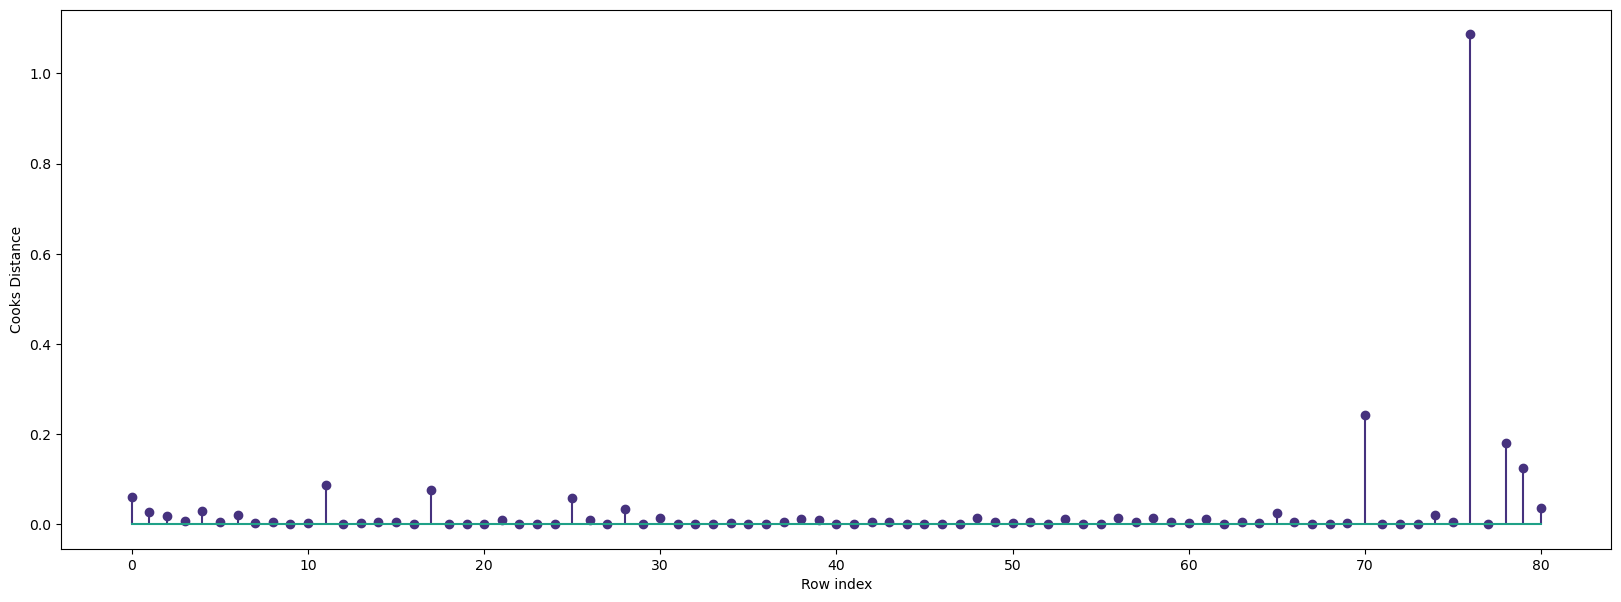

In [171]:
#Plot the influencers values using stem plot
fig = plt.subplots(figsize=(20, 7))
plt.stem(np.arange(len(cars_mil)), np.round(c, 3))
plt.xlabel('Row index')
plt.ylabel('Cooks Distance')
plt.show()

In [173]:
len(cars_mil)

81

In [183]:
np.round(c,3)# need to cehck with trainer how it is working


array([6.000e-02, 2.800e-02, 1.800e-02, 7.000e-03, 3.000e-02, 5.000e-03,
       2.100e-02, 3.000e-03, 4.000e-03, 1.000e-03, 3.000e-03, 8.700e-02,
       0.000e+00, 3.000e-03, 5.000e-03, 5.000e-03, 1.000e-03, 7.600e-02,
       1.000e-03, 1.000e-03, 0.000e+00, 1.000e-02, 0.000e+00, 0.000e+00,
       1.000e-03, 5.900e-02, 1.000e-02, 0.000e+00, 3.300e-02, 0.000e+00,
       1.300e-02, 1.000e-03, 0.000e+00, 1.000e-03, 3.000e-03, 0.000e+00,
       0.000e+00, 5.000e-03, 1.200e-02, 9.000e-03, 0.000e+00, 0.000e+00,
       4.000e-03, 4.000e-03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       1.300e-02, 5.000e-03, 3.000e-03, 5.000e-03, 0.000e+00, 1.100e-02,
       1.000e-03, 0.000e+00, 1.400e-02, 5.000e-03, 1.300e-02, 4.000e-03,
       3.000e-03, 1.100e-02, 1.000e-03, 4.000e-03, 3.000e-03, 2.400e-02,
       6.000e-03, 0.000e+00, 1.000e-03, 2.000e-03, 2.420e-01, 1.000e-03,
       0.000e+00, 0.000e+00, 2.000e-02, 4.000e-03, 1.087e+00, 1.000e-03,
       1.810e-01, 1.240e-01, 3.700e-02])

In [217]:
#index and value of influencer where c is more than .5
# C - cooks distance
(np.argmax(c),np.max(c)) #argmax will give us at what data point c value is max. Here at 76th date point is having max value of C is 1.0865
# And this point is having cooks distanec more than 1 so it needs to be removed

(76, 1.0865193998180098)

### High Influence points 
- to check the in visualised way

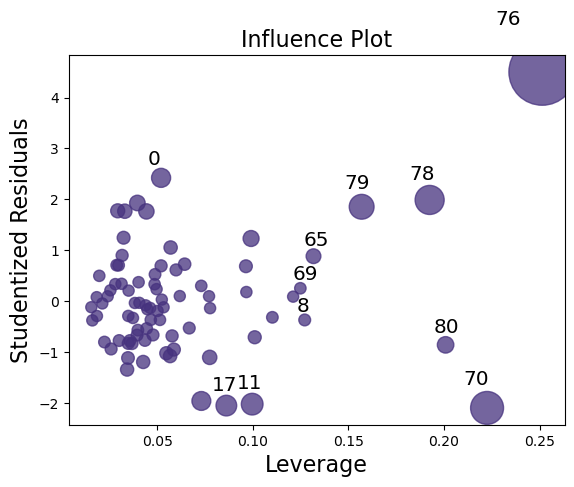

In [222]:
from statsmodels.graphics.regressionplots import influence_plot
influence_plot(cars_model)
plt.show()
# here in below plot it shows that data points at index 76,70,78,79 are having high influence

In [188]:
cars_mil.shape # the original data set are haing 81 rows and 5 column

(81, 5)

In [194]:
k = cars_mil.shape[1] # no of rows 
print(k)
n = cars_mil.shape[0] # no of rows
print(n)
leverage_cutoff = 3*((k + 1)/n)
leverage_cutoff

5
81


0.2222222222222222

#### From the above plot, and the value of leverage cutoff, it is evident that data point 70 and 76 are the influencers

In [197]:
cars_mil[cars_mil.index.isin([70, 76])] # check the vaalues for perticularly for 70,76. we need need to delete these 2 rows in next model and try

,HP,MPG,VOL,SP,WT
70,280,19.678507,50,164.598513,15.823060
76,322,36.900000,50,169.598513,16.132947


In [201]:
#See the differences in HP and other variable values
cars_mil.head()

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149


# Improving the model - try 2

In [203]:
#Load the data
cars_new = pd.read_csv("Cars.csv")

In [205]:
#Discard the data points which are influencers and reasign the row number (reset_index())
car1=cars_new.drop(cars_new.index[[70,76]],axis=0).reset_index()
car1

,index,HP,MPG,VOL,SP,WT
0,0,49,53.700681,89,104.185353,28.762059
1,1,55,50.013401,92,105.461264,30.466833
2,2,55,50.013401,92,105.461264,30.193597
3,3,70,45.696322,92,113.461264,30.632114
4,4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...,...
74,75,175,18.762837,129,132.864163,42.778219
75,77,238,19.197888,115,150.576579,37.923113
76,78,263,34.000000,50,151.598513,15.769625
77,79,295,19.833733,119,167.944460,39.423099


In [207]:
#Drop the original index
car1=car1.drop(['index'],axis=1)

In [209]:
car1

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
74,175,18.762837,129,132.864163,42.778219
75,238,19.197888,115,150.576579,37.923113
76,263,34.000000,50,151.598513,15.769625
77,295,19.833733,119,167.944460,39.423099


## Build Model - try 2

In [214]:
#Exclude variable "WT" and generate R-Squared and AIC values
final_ml_V= smf.ols('MPG~VOL+SP+HP',data = car1).fit()
final_ml_V.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    MPG   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.809
Method:                 Least Squares   F-statistic:                     111.0
Date:                Mon, 07 Apr 2025   Prob (F-statistic):           1.65e-27
Time:                        16:56:07   Log-Likelihood:                -219.06
No. Observations:                  79   AIC:                             446.1
Df Residuals:                      75   BIC:                             455.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     25.5275     13.051      1.956      0.054      -0.471      51.526
VOL           -0.1825      0.023     -8.012      0.000      -0.228      -0.137
SP             0.4415      0.141      3.124      0.003       0.160       0.723
HP            -0.2291      0.035     -6.592      0.000      -0.298      -0.160
==============================================================================
Omnibus:                        6.541   Durbin-Watson:                   1.130
Prob(Omnibus):                  0.038   Jarque-Bera (JB):                5.833
Skew:                           0.620   Prob(JB):                       0.0541
Kurtosis:                       3.485   Cond. No.                     5.76e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.76e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [216]:
(final_ml_V.rsquared,final_ml_V.aic)

(0.8161692010376007, 446.11722639447726)

In [218]:
#Exclude variable "VOL" and generate R-Squared and AIC values
final_ml_W= smf.ols('MPG~WT+SP+HP',data = car1).fit()

In [220]:
(final_ml_W.rsquared,final_ml_W.aic)

(0.8160034320495304, 446.1884323575032)

##### Comparing above R-Square and AIC values, model 'final_ml_V' has high R- square and low AIC value hence include variable 'VOL' and ignore 'WT' so that multi collinearity problem would be resolved.

## Cook’s Distance - try 2

In [224]:
model_influence_V = final_ml_V.get_influence()
(c_V, _) = model_influence_V.cooks_distance

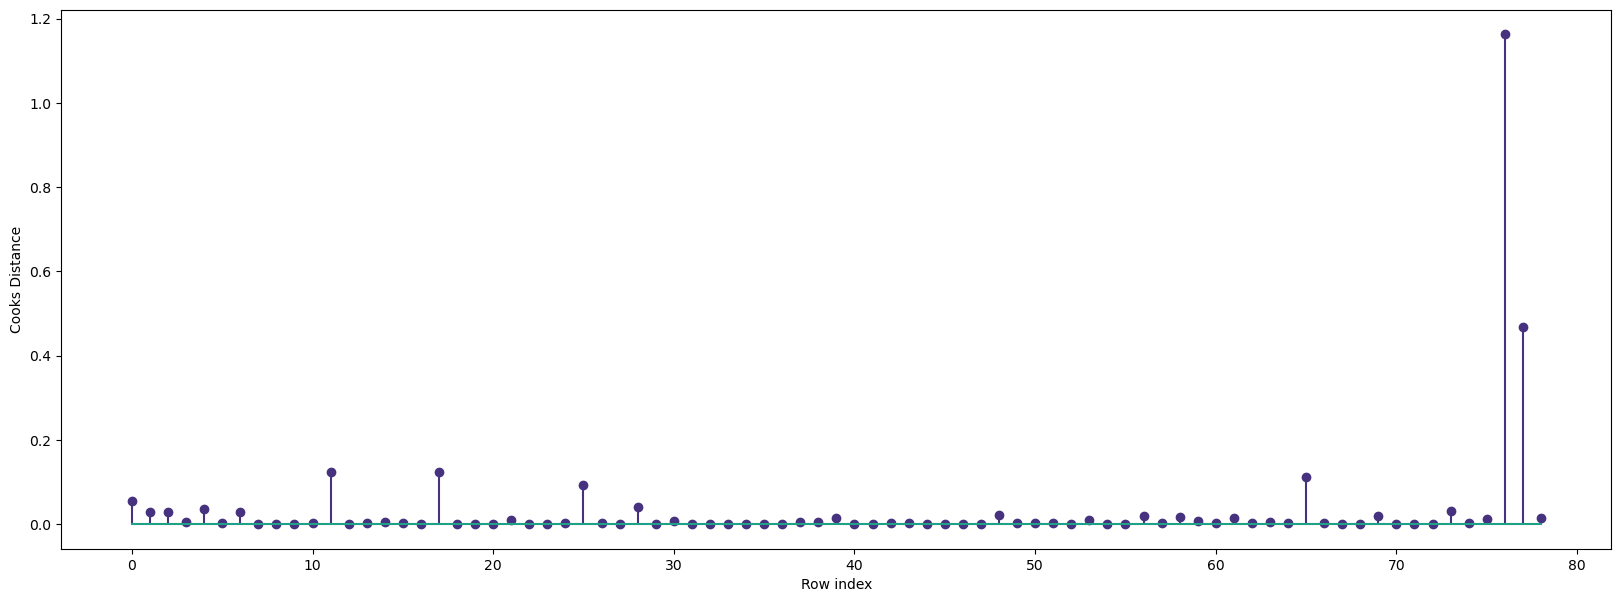

In [226]:
fig= plt.subplots(figsize=(20,7))
plt.stem(np.arange(len(car1)),np.round(c_V,3));
plt.xlabel('Row index')
plt.ylabel('Cooks Distance');

In [228]:
#index of the data points where c is more than .5
(np.argmax(c_V),np.max(c_V))

(76, 1.1629387469135095)

In [230]:
#Drop 76 and 77 observations
car2=car1.drop(car1.index[[76,77]],axis=0)

In [232]:
car2

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
72,140,19.086341,160,124.715241,52.997752
73,140,19.086341,129,121.864163,42.618698
74,175,18.762837,129,132.864163,42.778219
75,238,19.197888,115,150.576579,37.923113


In [234]:
#Reset the index and re arrange the row values
car3=car2.reset_index(drop=True)

In [236]:
car3

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149
...,...,...,...,...,...
72,140,19.086341,160,124.715241,52.997752
73,140,19.086341,129,121.864163,42.618698
74,175,18.762837,129,132.864163,42.778219
75,238,19.197888,115,150.576579,37.923113


In [238]:
car4 = car3

## Build Model - try 3 final

In [241]:
#Build the model on the new data
final_ml_V= smf.ols('MPG~VOL+SP+HP',data = car4).fit()

In [243]:
#Again check for influencers
model_influence_V = final_ml_V.get_influence()
(c_V, _) = model_influence_V.cooks_distance

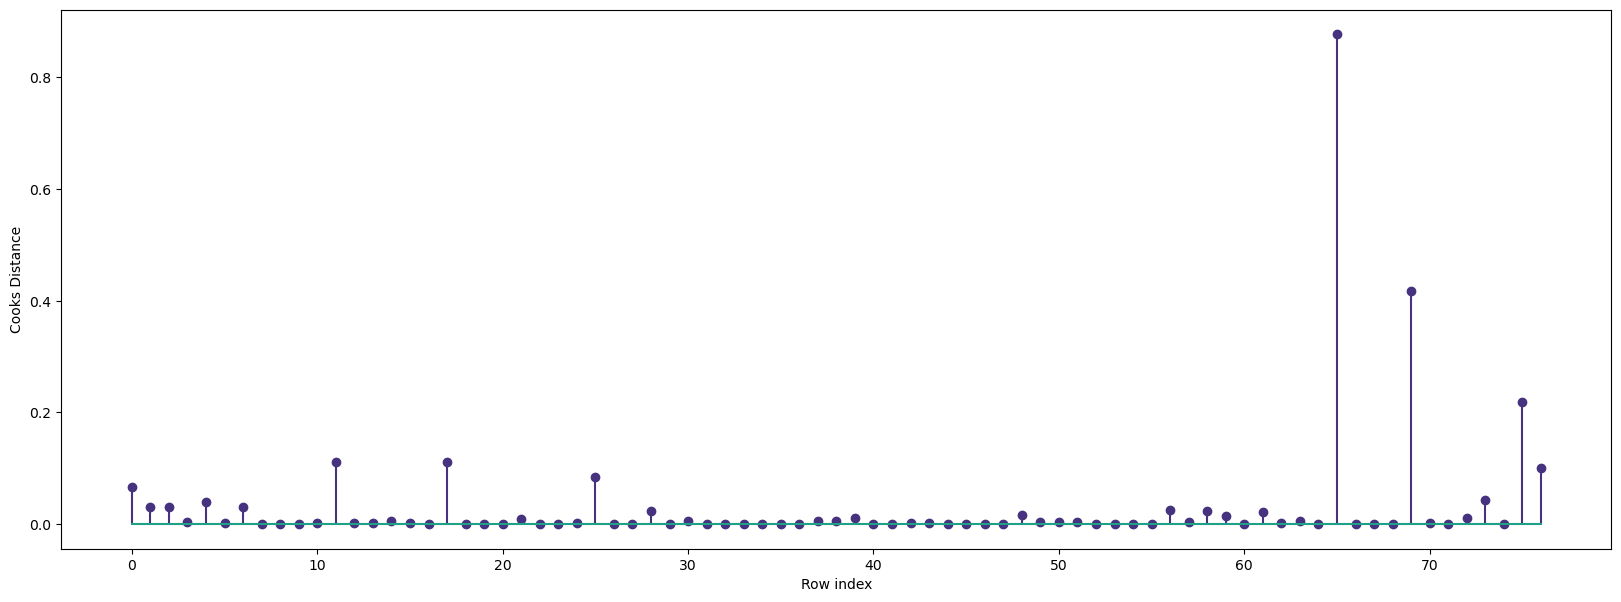

In [245]:
fig= plt.subplots(figsize=(20,7))
plt.stem(np.arange(len(car4)),np.round(c_V,3));
plt.xlabel('Row index')
plt.ylabel('Cooks Distance');

In [247]:
#index of the data points where c is more than .5
(np.argmax(c_V),np.max(c_V))

(65, 0.8774556986296826)

#### Since the value is <1 , we can stop the diagnostic process and finalize the model

In [250]:
#Check the accuracy of the mode
final_ml_V= smf.ols('MPG~VOL+SP+HP',data = car4).fit()

In [252]:
final_ml_V.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    MPG   R-squared:                       0.867
Model:                            OLS   Adj. R-squared:                  0.861
Method:                 Least Squares   F-statistic:                     158.6
Date:                Mon, 07 Apr 2025   Prob (F-statistic):           6.81e-32
Time:                        17:04:49   Log-Likelihood:                -200.71
No. Observations:                  77   AIC:                             409.4
Df Residuals:                      73   BIC:                             418.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     25.2974     11.336      2.232      0.029       2.706      47.889
VOL           -0.1362      0.021     -6.366      0.000      -0.179      -0.094
SP             0.4335      0.122      3.560      0.001       0.191       0.676
HP            -0.2635      0.031     -8.634      0.000      -0.324      -0.203
==============================================================================
Omnibus:                        9.478   Durbin-Watson:                   1.195
Prob(Omnibus):                  0.009   Jarque-Bera (JB):                9.184
Skew:                           0.770   Prob(JB):                       0.0101
Kurtosis:                       3.703   Cond. No.                     5.72e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.72e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
- Now we can observe that R2 s increasing and AIC is gecreasing, means our model is improving.

In [254]:
#New data for prediction
new_data=pd.DataFrame({'HP':40,"VOL":95,"SP":102},index=[1])
new_data

,HP,VOL,SP
1,40,95,102


In [256]:
final_ml_V.predict(new_data)


1    46.035594
dtype: float64

In [258]:
final_ml_V.predict(cars_new.iloc[0:5,])

0    45.428872
1    43.992392
2    43.992392
3    43.508150
4    44.085858
dtype: float64

In [260]:
cars_new.head()

,HP,MPG,VOL,SP,WT
0,49,53.700681,89,104.185353,28.762059
1,55,50.013401,92,105.461264,30.466833
2,55,50.013401,92,105.461264,30.193597
3,70,45.696322,92,113.461264,30.632114
4,53,50.504232,92,104.461264,29.889149


In [262]:
pred_y = final_ml_V.predict(cars_new)

In [264]:
pred_y

0     45.428872
1     43.992392
2     43.992392
3     43.508150
4     44.085858
        ...    
76     7.165876
77    12.198598
78    14.908588
79     4.163958
80     9.161202
Length: 81, dtype: float64